In [1]:
import pandas as pd
df=pd.read_csv("/content/bank.csv")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [2]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df.shape

(11162, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [7]:
y=df.deposit
y

,deposit
0,yes
1,yes
2,yes
3,yes
4,yes
...,...
11157,no
11158,no
11159,no
11160,no


In [8]:
y.value_counts()

,count
deposit,
no,5873
yes,5289


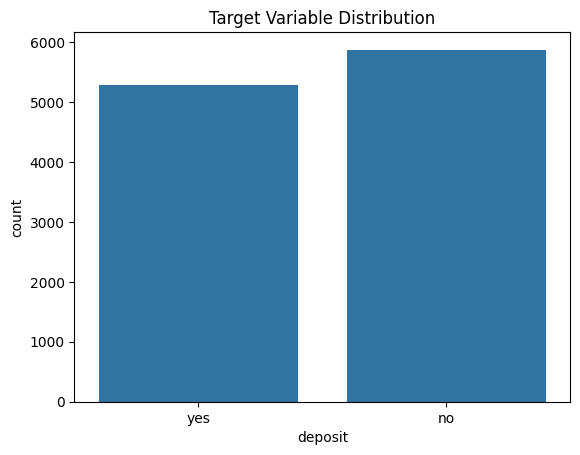

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='deposit',data=df)
plt.title("Target Variable Distribution")
plt.show()

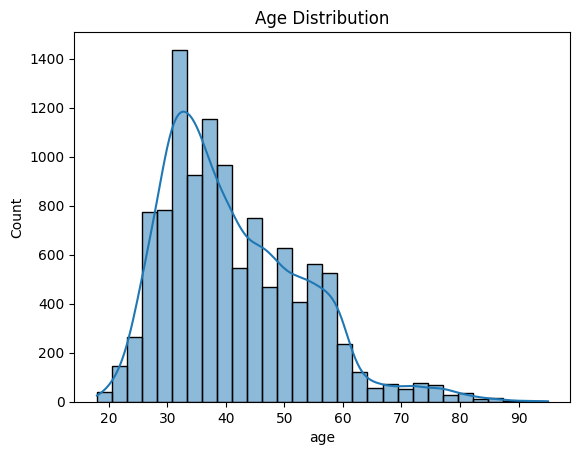

In [10]:
sns.histplot(df["age"],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()


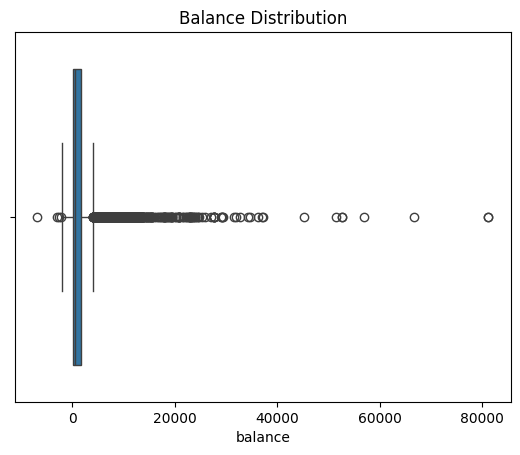

In [11]:
sns.boxplot(x=df["balance"])
plt.title("Balance Distribution")
plt.show()

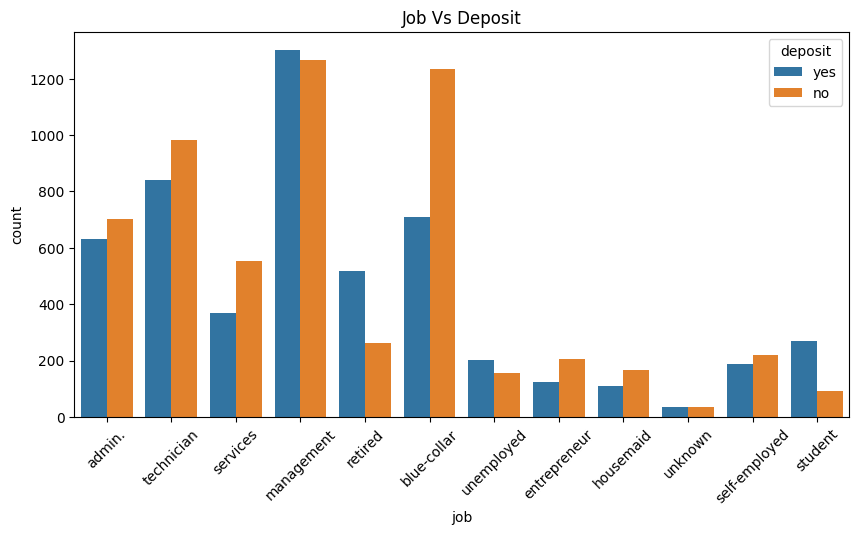

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(x='job',hue='deposit',data=df)
plt.xticks(rotation=45)
plt.title("Job Vs Deposit")
plt.show()

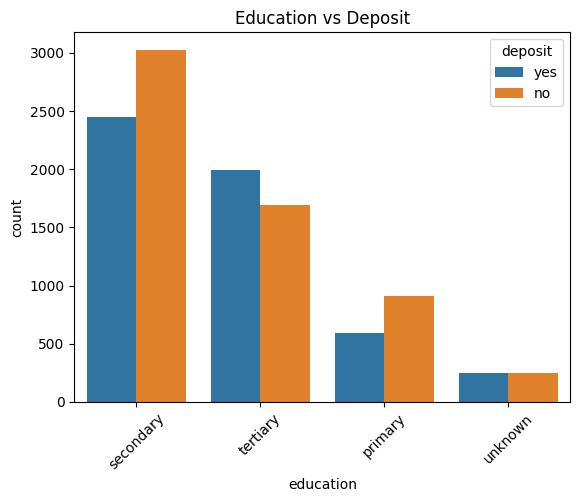

In [13]:
sns.countplot(x='education',hue='deposit',data=df)
plt.xticks(rotation=45)
plt.title("Education vs Deposit")
plt.show()

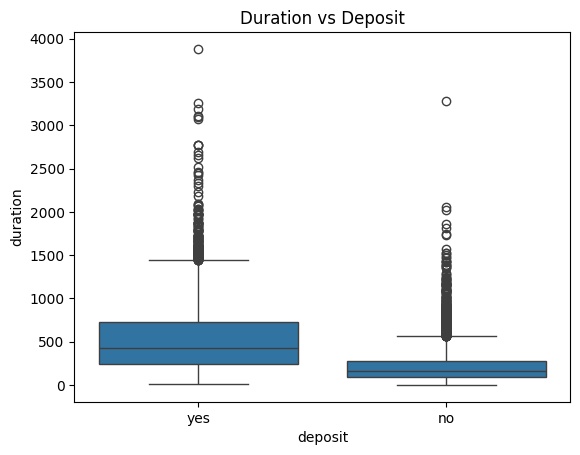

In [14]:
sns.boxplot(x='deposit',y='duration',data=df)
plt.title("Duration vs Deposit")
plt.show()

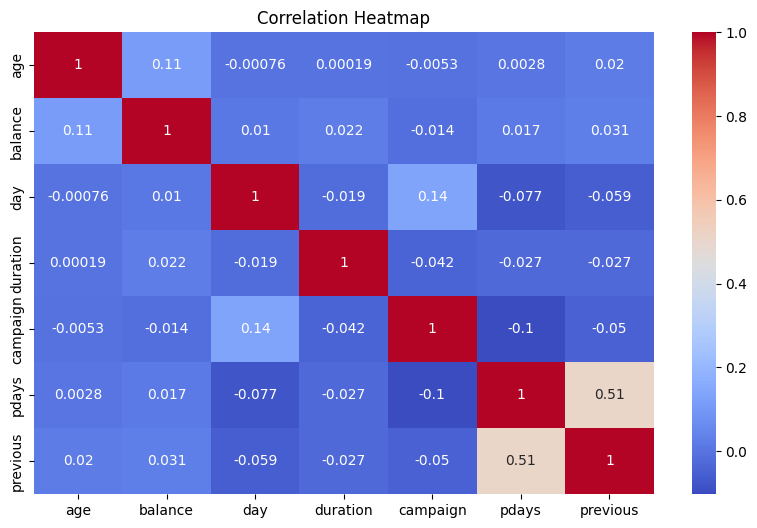

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
df['deposit']=df["deposit"].map({'no':0,'yes':1})


In [17]:
df_encoded=pd.get_dummies(df,drop_first=True)
df_encoded

,age,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0,0,True,False,...,False,False,False,False,False,False,False,False,False,True
11158,39,733,16,83,4,-1,0,0,False,False,...,False,True,False,False,False,False,False,False,False,True
11159,32,29,19,156,2,-1,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True
11160,43,0,8,9,2,172,5,0,False,False,...,False,False,False,True,False,False,False,False,False,False


In [18]:
from sklearn.preprocessing import LabelEncoder
x=df_encoded.drop('deposit',axis=1)
y=df_encoded['deposit']


In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [20]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


In [21]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [22]:
ypred=knn.predict(x_test)

In [37]:
acc=accuracy_score(y_test,ypred)
acc

0.8535602328705777

In [24]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [25]:
y_pred_lr=lr.predict(x_test)

In [26]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
accuracy_score(y_test,y_pred_lr)

0.8262427227944469

In [27]:
cm=confusion_matrix(y_test,y_pred_lr)
cm

array([[1017,  188],
       [ 200,  828]])

In [28]:
classification_report(y_test,y_pred_lr)

'              precision    recall  f1-score   support\n\n           0       0.84      0.84      0.84      1205\n           1       0.81      0.81      0.81      1028\n\n    accuracy                           0.83      2233\n   macro avg       0.83      0.82      0.82      2233\nweighted avg       0.83      0.83      0.83      2233\n'

In [29]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [30]:
ypred=dt.predict(x_test)

In [31]:
accuracy_score(y_test,ypred)

0.7689207344379758

In [32]:
confusion_matrix(y_test,ypred)

array([[964, 241],
       [275, 753]])

In [33]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [34]:
ypred=rf.predict(x_test)

In [35]:
accuracy_score(y_test,ypred)

0.8535602328705777